# Comparison Metrics

In [2]:
import pandas as pd
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import os 
os.makedirs('benchmark_fig', exist_ok=True)
import numpy as np

In [3]:
# Mapping & Pallettes
samples = ['mouse_brain','mouse_embryo','mouse_kidney','mouse_intestine','human_lung', 'human_colon']

method_map = {
    'cyto_filtered_naive_8um': 'Naive 8um',
    'cyto_filtered_stardist_proximity': 'StarDist + Proximity',
    'cyto_filtered_stardist_voronoi': 'StarDist + Voronoi',
    'nuc_filtered_stardist': 'StarDist Nuclei',
    'cyto_filtered_cellpose_proximity': 'Cellpose + Proximity',
    'cyto_filtered_cellpose_voronoi': 'Cellpose + Voronoi',
    'cyto_filtered_cellpose': 'Cellpose3 Cytoplasm',
    'nuc_filtered_cellpose': 'Cellpose Nuclei',
    'cyto_filtered_bin2cell': 'Bin2Cell Cytoplasm',
    'cyto_filtered_STP_tuned': 'STP Tuned',
    'cyto_filtered_STP_untuned': 'STP Untuned',
}
plot_order = [
    'Naive 8um',
    'Cellpose3 Cytoplasm',
    'Bin2Cell Cytoplasm',
    'StarDist Nuclei',
    'StarDist + Proximity',
    'StarDist + Voronoi',
    'STP Tuned',
    'STP Untuned',
    'Cellpose Nuclei',
    'Cellpose + Proximity',
    'Cellpose + Voronoi'
]


color_map = [
    "#66c2a5",  # soft mint green
    "#fc8d62",  # soft coral
    "#8da0cb",  # muted periwinkle
    "#e78ac3",  # muted orchid
    "#a6d854",  # olive green
    "#ffd92f"   # soft yellow
]

tissues = ['Mouse Brain', 'Mouse Embryo', 'Mouse Kidney', 'Mouse Intestine', 'Human Lung', 'Human Colon']



In [4]:
data = {}
merged_dfs = {}
for sample in samples:
    # Paths to data files
    path = f'/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/{sample}/{sample}_run/plots/overview/'
    cell_counts_csv = path+"total_cell_calls.csv"
    umi_per_cell_csv = path+"total_UMI_per_cell.csv"
    area_per_cell_csv = path+"total_area_per_cell.csv"
    umi_per_area_csv = path+"total_UMI_per_area_per_cell.csv"
    transcript_capture_csv = path+"roi_transcripts_summary.csv"

    # Load data and store in a dictionary under the sample name
    cell_counts = pd.read_csv(cell_counts_csv)
    data[f"{sample}_cell_counts_df"] = cell_counts
    umi_per_cell = pd.read_csv(umi_per_cell_csv)
    data[f"{sample}_umi_df"] = umi_per_cell
    area_per_cell = pd.read_csv(area_per_cell_csv)
    data[f"{sample}_area_df"] = area_per_cell
    umi_per_area = pd.read_csv(umi_per_area_csv)
    data[f"{sample}_umi_per_area_df"] = umi_per_area
    transcript_capture = pd.read_csv(transcript_capture_csv)
    data[f"{sample}_transcript_capture_df"] = transcript_capture
    ari_segmentation = pd.read_csv(path+"ARI_segmentation.csv")
    data[f"{sample}_ari_df"] = ari_segmentation

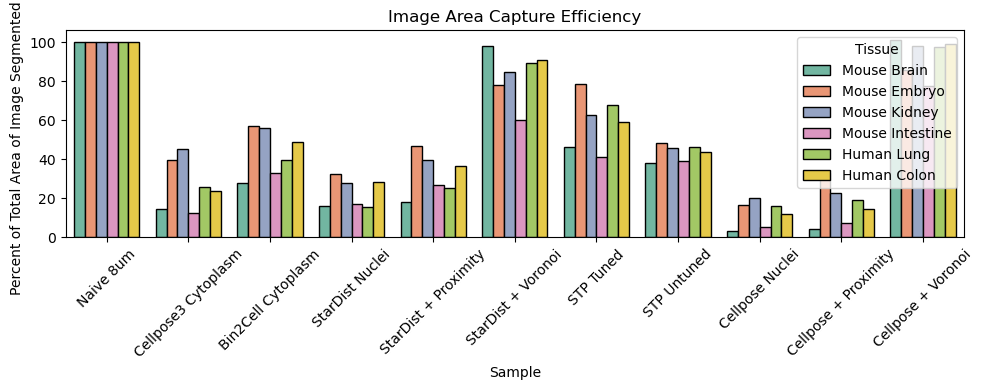

In [5]:
# Collect transcript capture DataFrames from data dict
transcript_capture_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_transcript_capture_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    transcript_capture_list.append(df)

# Combine into a single DataFrame
perc_area_df = pd.concat(transcript_capture_list).reset_index(drop=True)
# delete bin2cell nuclei
perc_area_df = perc_area_df[perc_area_df['Sample'] != 'nuc_filtered_bin2cell']
perc_area_df['Sample'] = perc_area_df['Sample'].replace(method_map)
fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    x="Sample",
    y="Percent_Area_Segmented",
    data=perc_area_df,
    hue="Tissue",
    edgecolor="black",
    order=plot_order,
    palette=color_map,
    ax=ax 
)

ax.set_ylabel("Percent of Total Area of Image Segmented (%)")
ax.set_title("Image Area Capture Efficiency")
ax.tick_params(axis='x', rotation=45, labelrotation=45)

fig.tight_layout()
fig.savefig('benchmark_fig/area_capture_barplot.pdf')
plt.show()
plt.close()

In [6]:
perc_area_df[['Percent_Area_Segmented', 'Sample']].groupby(['Sample']).mean()

,Percent_Area_Segmented
Sample,
Bin2Cell Cytoplasm,43.753556
Cellpose + Proximity,16.830675
Cellpose + Voronoi,93.123640
Cellpose Nuclei,12.239706
Cellpose3 Cytoplasm,27.052910
Naive 8um,100.000000
STP Tuned,59.296890
STP Untuned,43.552471
StarDist + Proximity,32.242128


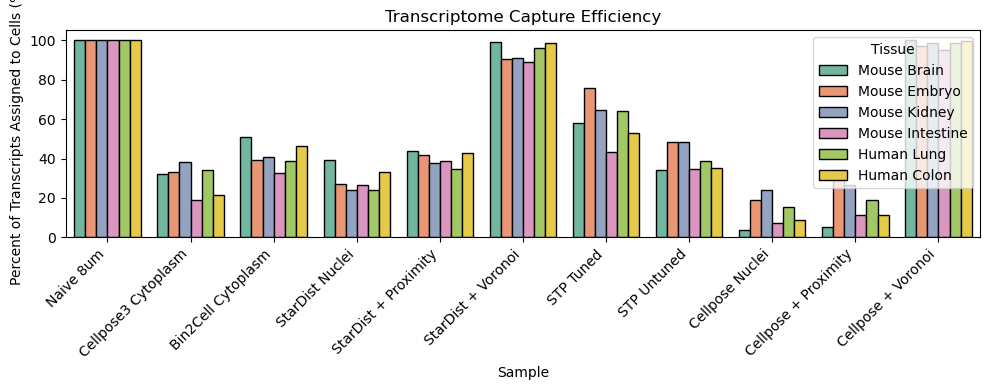

In [7]:
# Collect transcript capture DataFrames from data dict
transcript_capture_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_transcript_capture_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    transcript_capture_list.append(df)

# Combine into a single DataFrame
perc_transcript_df = pd.concat(transcript_capture_list).reset_index(drop=True)
# delete bin2cell nuclei
perc_transcript_df = perc_transcript_df[perc_transcript_df['Sample'] != 'nuc_filtered_bin2cell']
perc_transcript_df['Sample'] = perc_transcript_df['Sample'].replace(method_map)
fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    x="Sample",
    y="Percent_Transcripts_Segmented",
    data=perc_transcript_df,
    hue="Tissue",
    edgecolor="black",
    order=plot_order,
    palette=color_map,
    ax=ax     
)
plt.ylabel("Percent of Transcripts Assigned to Cells (%)")
plt.title("Transcriptome Capture Efficiency")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.savefig('benchmark_fig/transcript_capture_barplot.pdf')
plt.show()
plt.close()

In [8]:
perc_transcript_df[['Percent_Transcripts_Segmented', 'Sample']].groupby(['Sample']).mean()

,Percent_Transcripts_Segmented
Sample,
Bin2Cell Cytoplasm,41.491073
Cellpose + Proximity,17.884053
Cellpose + Voronoi,98.145384
Cellpose Nuclei,13.142288
Cellpose3 Cytoplasm,29.725271
Naive 8um,100.000000
STP Tuned,59.693714
STP Untuned,40.020360
StarDist + Proximity,39.957817


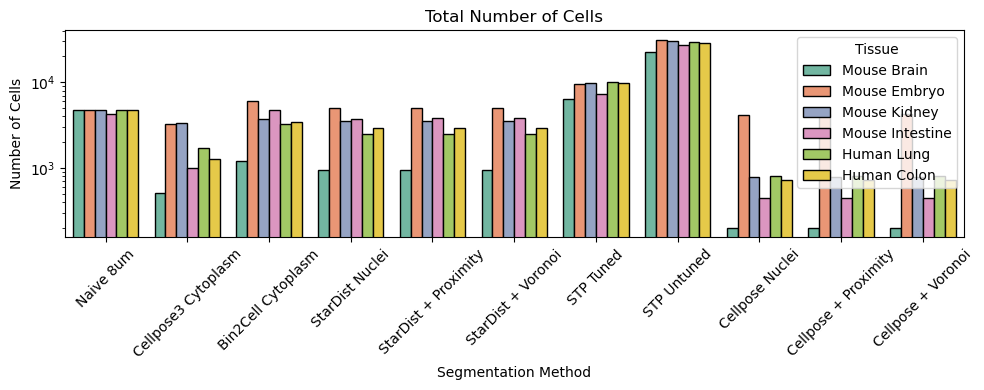

In [9]:
# Collect all cell counts DataFrames into a list, adding a 'Tissue' column to each
cell_counts_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_cell_counts_df"].copy()
    df['Tissue'] = tissue
    cell_counts_list.append(df)

# Combine into a single DataFrame
num_cells_df = pd.concat(cell_counts_list)
# delete bin2cell nuclei
num_cells_df = num_cells_df[num_cells_df['Sample'] != 'nuc_filtered_bin2cell']
num_cells_df['Sample'] = num_cells_df['Sample'].replace(method_map)

fig, ax = plt.subplots(figsize=(10, 4))

sns.barplot(
    x="Sample",
    y="Cell_Count",
    hue="Tissue",
    data=num_cells_df,
    order=plot_order,
    palette=color_map,
    edgecolor="black",
    legend=True,
    ax=ax         
)

ax.set_ylabel("Number of Cells")
ax.set_xlabel("Segmentation Method")
ax.set_title("Total Number of Cells")
ax.tick_params(axis='x', rotation=45)

ax.set_yscale('log')

fig.tight_layout()
fig.savefig('benchmark_fig/total_cell_counts_barplot.pdf')
plt.show()
plt.close()

/tmp/ipykernel_2780532/1061531551.py:18: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2780532/1061531551.py:33: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0)


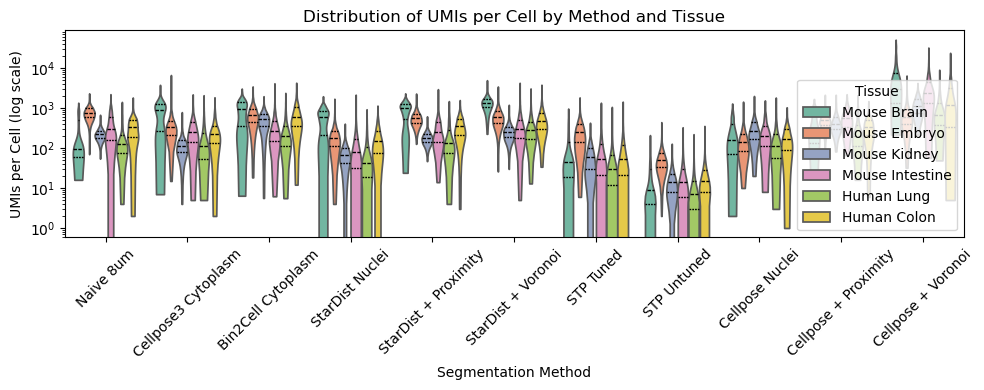

In [10]:
# Collect UMI DataFrames from data dict
umi_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_umi_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    umi_list.append(df)

# Combine into a single DataFrame

umi_per_cell_df = pd.concat(umi_list)
# delete bin2cell nuclei
umi_per_cell_df = umi_per_cell_df[umi_per_cell_df['Sample'] != 'nuc_filtered_bin2cell']
umi_per_cell_df['Sample'] = umi_per_cell_df['Sample'].replace(method_map)

fig, ax = plt.subplots(figsize=(10, 4))

sns.violinplot(
    x="Sample",
    y="UMI_per_cell",
    data=umi_per_cell_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth": 1},
    cut=0,
    ax=ax    
)

ax.set_yscale("log")
ax.set_ylim(0)
ax.tick_params(axis='x', rotation=45)

ax.set_ylabel("UMIs per Cell (log scale)")
ax.set_xlabel("Segmentation Method")
ax.set_title("Distribution of UMIs per Cell by Method and Tissue")

fig.tight_layout()
fig.savefig('benchmark_fig/umi_per_cell_violinplot.pdf', bbox_inches='tight')
plt.show()
plt.close()

# Area of Cells

/tmp/ipykernel_2780532/2603235051.py:17: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


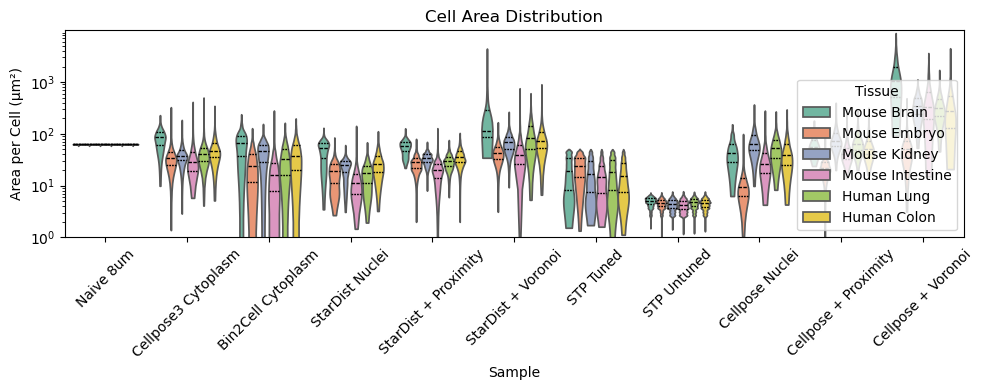

In [11]:
# Collect area DataFrames from data dict
area_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_area_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    area_list.append(df)

# Combine into a single DataFrame
cell_area_df = pd.concat(area_list)
# delete bin2cell nuclei
cell_area_df = cell_area_df[cell_area_df['Sample'] != 'nuc_filtered_bin2cell']
cell_area_df['Sample'] = cell_area_df['Sample'].replace(method_map)

fig, ax = plt.subplots(figsize=(10, 4))

sns.violinplot(
    x="Sample",
    y="Area_per_cell",
    data=cell_area_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": "-", "linewidth": 1},
    cut=0,
    legend=True,
    ax=ax            
)

ax.set_ylabel("Area per Cell (µm²)")
ax.set_title("Cell Area Distribution")
ax.tick_params(axis='x', rotation=45)

# log scale + fixed ticks
ax.set_yscale('log')
ticks = [10**i for i in range(0, 4)]
ax.set_yticks(ticks)
ax.set_yticklabels([f"$10^{i}$" for i in range(0, 4)])
ax.set_ylim(1, 10000)

fig.tight_layout()
fig.savefig('benchmark_fig/area_per_cell_violinplot.pdf')
plt.show()
plt.close()


# UMI per Area

/tmp/ipykernel_2780532/4217233522.py:18: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


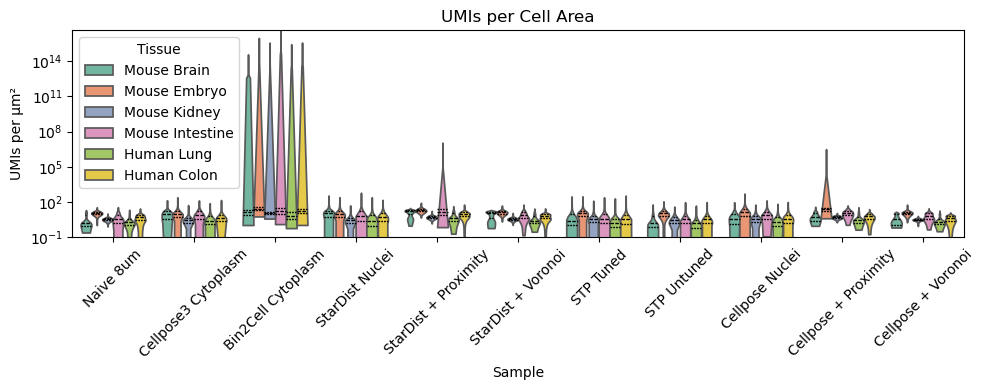

In [12]:
# Collect UMI-per-area DataFrames from data dict
umi_per_area_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_umi_per_area_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    umi_per_area_list.append(df)

# Combine into a single DataFrame

transcript_conc_df = pd.concat(umi_per_area_list).reset_index(drop=True)
# delete bin2cell nuclei
transcript_conc_df = transcript_conc_df[transcript_conc_df['Sample'] != 'nuc_filtered_bin2cell']
transcript_conc_df['Sample'] = transcript_conc_df['Sample'].replace(method_map)

fig, ax = plt.subplots(figsize=(10, 4))

sns.violinplot(
    x="Sample",
    y="UMI_per_area",
    data=transcript_conc_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth":1},
    cut=0,
    legend=True,
    ax=ax        
)

ax.set_ylabel("UMIs per µm²")
ax.set_title("UMIs per Cell Area")
ax.tick_params(axis='x', rotation=45)

ax.set_ylim(0.1)
ax.set_yscale('log')

fig.tight_layout()
fig.savefig('benchmark_fig/umi_per_area_violinplot.pdf')
plt.show()
plt.close()

/tmp/ipykernel_2780532/1273662924.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


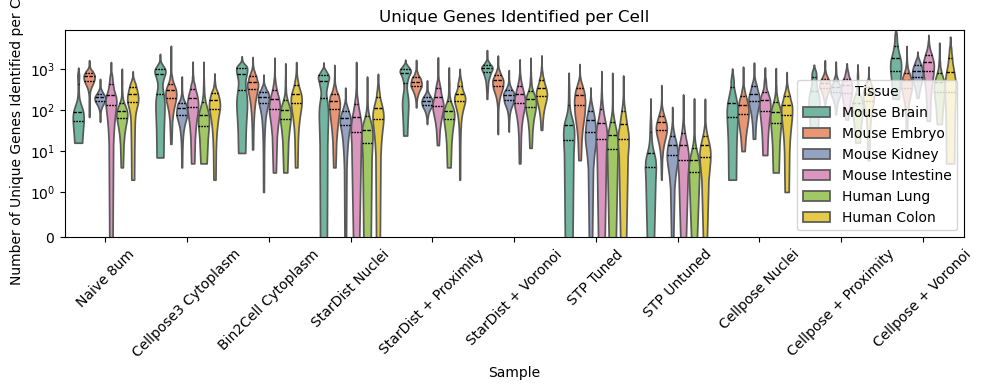

In [13]:
# Collect UMI DataFrames from data dict
unique_gene_list = []

for sample, tissue in zip(samples, tissues):
    df = data[f"{sample}_umi_df"].copy()
    df['Tissue'] = tissue  # Add tissue label column
    unique_gene_list.append(df)

# Combine into a single DataFrame, ensuring unique indices
unique_genes_df = pd.concat([df.reset_index(drop=True) for df in unique_gene_list])
unique_genes_df = unique_genes_df.reset_index(drop=True)
unique_genes_df['Sample'] = unique_genes_df['Sample'].replace(method_map)

fig, ax = plt.subplots(figsize=(10, 4))

sns.violinplot(
    x="Sample", 
    y="Unique_Genes", 
    data=unique_genes_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth":1},
    cut=0,
    legend=True,
    ax=ax,  
)

ax.set_ylabel("Number of Unique Genes Identified per Cell")
ax.set_title("Unique Genes Identified per Cell")
ax.tick_params(axis='x', rotation=45)

ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0)

plt.tight_layout()
fig.savefig("benchmark_fig/unique_genes_per_cell_violinplot.pdf")
plt.show()

In [15]:
# groupby Sample and calculate mean Unique Genes
unique_genes_df[['Unique_Genes', 'Sample']].groupby(['Sample']).mean()

,Unique_Genes
Sample,
Bin2Cell Cytoplasm,336.604183
Cellpose + Proximity,423.429260
Cellpose + Voronoi,864.806909
Cellpose Nuclei,182.214799
Cellpose3 Cytoplasm,237.723679
Naive 8um,313.162255
STP Tuned,106.483881
STP Untuned,24.694018
StarDist + Proximity,331.819369


In [3]:
# Bin2cell vs StarDist
415.9/146

2.8486301369863014

In [16]:
# Create a new column to group by based on whether 'Sample' contains 'Nuclei' or 'Voronoi'
unique_genes_df['Group'] = unique_genes_df['Sample'].apply(
    lambda x: 'Nuclei' if 'Nuclei' in x else ('Voronoi' if 'Voronoi' in x else 'Other')
)

# Group by the new 'Group' column and calculate the mean of 'Unique_Genes'
result = unique_genes_df.groupby('Group')['Unique_Genes'].mean()

print(result)

Group
Nuclei     156.036234
Other      124.209779
Voronoi    541.639991
Name: Unique_Genes, dtype: float64


In [18]:
fold_increase = result['Voronoi'] / result['Nuclei']

print(f"Fold increase (Nuclei vs Voronoi): {fold_increase}")

Fold increase (Nuclei vs Voronoi): 3.4712449497711058


/tmp/ipykernel_2960763/2737026362.py:57: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2960763/2737026362.py:72: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[3].set_ylim(0)
/tmp/ipykernel_2960763/2737026362.py:80: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2960763/2737026362.py:107: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2960763/2737026362.py:132: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


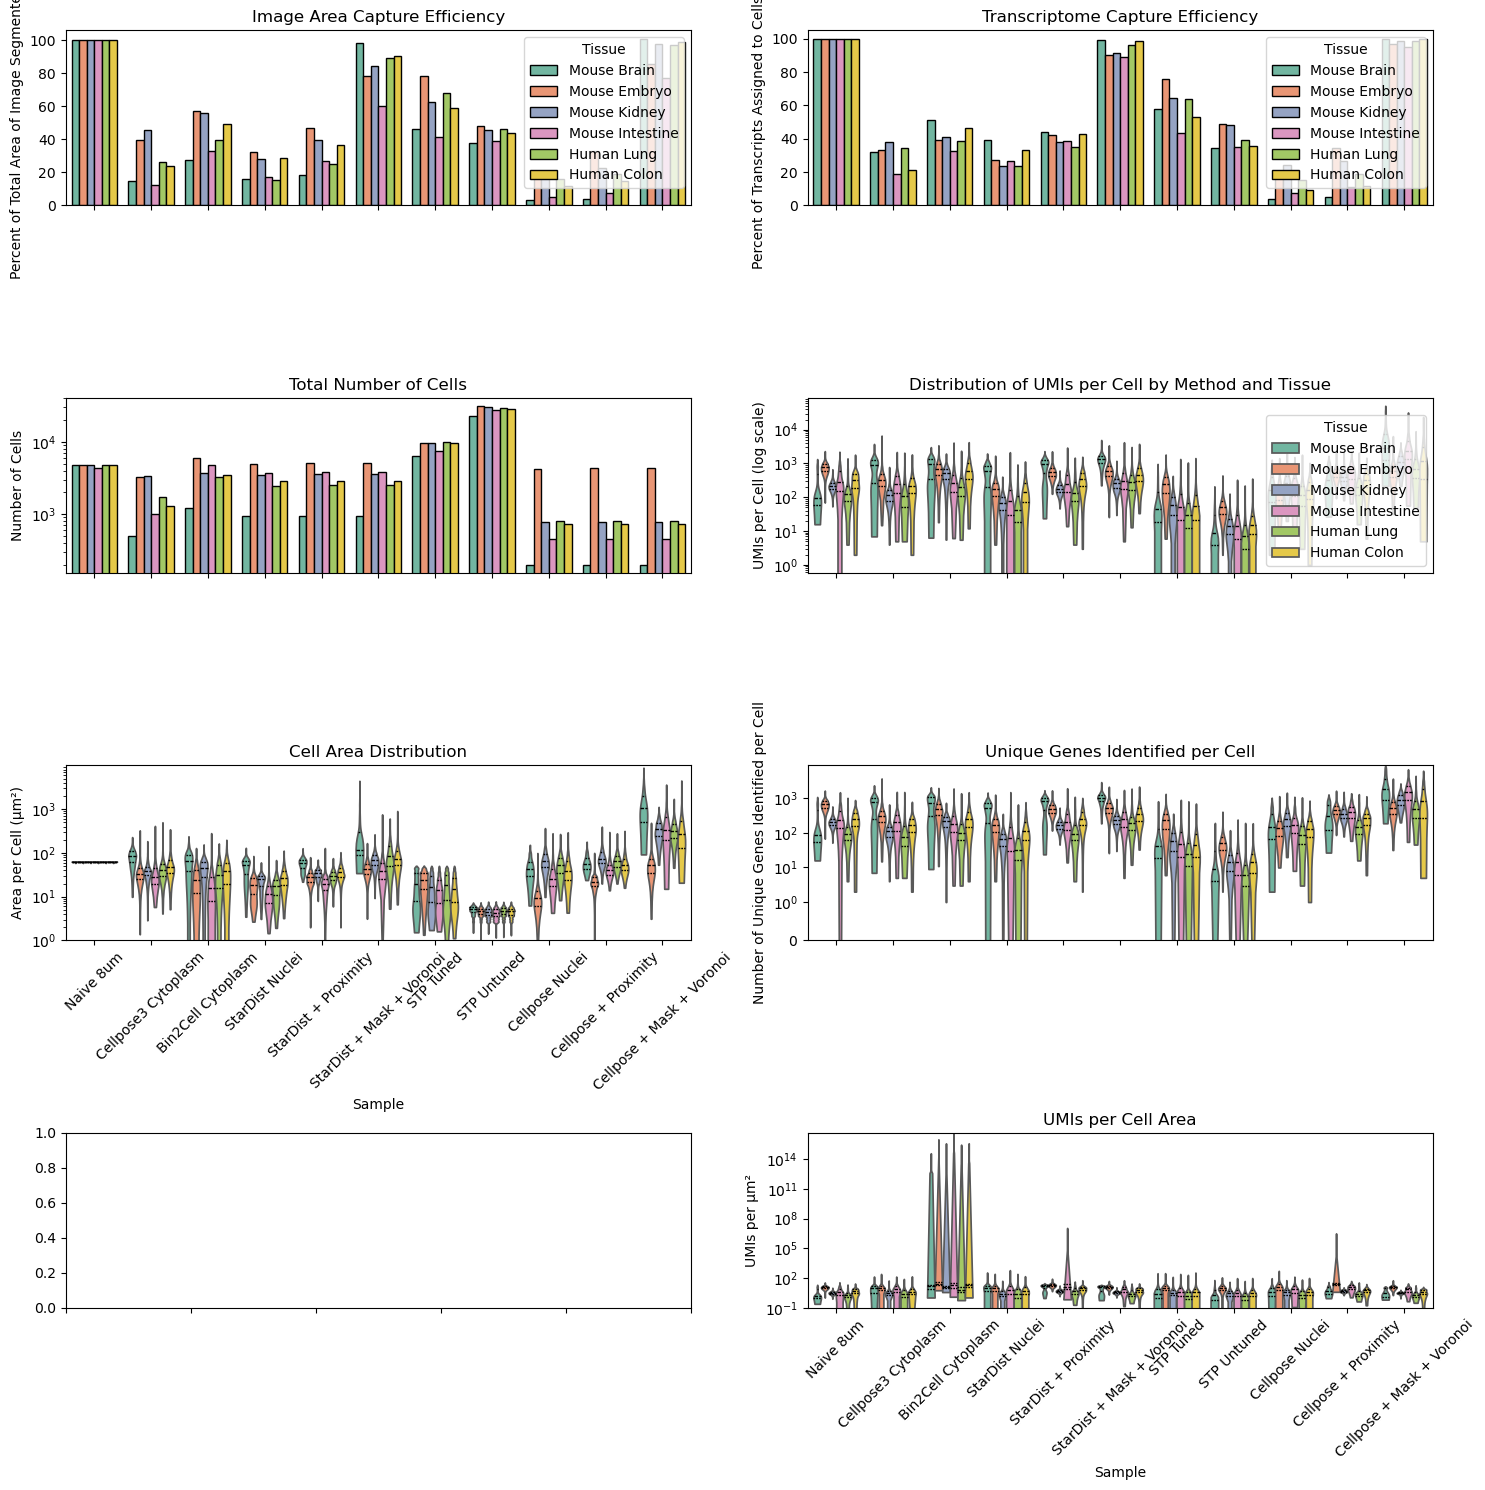

In [13]:
# Create 4x2 figure for 7 panels + empty 8th for legend
fig, axs = plt.subplots(4, 2, figsize=(15, 15))
axs = axs.flatten()

# Plot 1: Total Area Segmented
sns.barplot(
    x="Sample",
    y="Percent_Area_Segmented",
    data=perc_area_df,
    hue="Tissue",
    edgecolor="black",
    order=plot_order,
    palette=color_map,
    ax=axs[0]
)

axs[0].set_ylabel("Percent of Total Area of Image Segmented (%)")
axs[0].set_title("Image Area Capture Efficiency")
axs[0].tick_params(axis='x', rotation=45, labelrotation=45)

# Plot 2: Total Transcript Capture
sns.barplot(
    x="Sample",
    y="Percent_Transcripts_Segmented",
    data=perc_transcript_df,
    hue="Tissue",
    edgecolor="black",
    order=plot_order,
    palette=color_map,
    ax=axs[1]    
)

axs[1].set_ylabel("Percent of Transcripts Assigned to Cells (%)")
axs[1].set_title("Transcriptome Capture Efficiency")
axs[1].tick_params(axis='x', rotation=45, labelrotation=45)

# Plot 3: Total Number of Cells
sns.barplot(
    x="Sample",
    y="Cell_Count",
    hue="Tissue",
    data=num_cells_df,
    order=plot_order,
    palette=color_map,
    edgecolor="black",
    legend=False,
    ax=axs[2]         
)

axs[2].set_ylabel("Number of Cells")
axs[2].set_xlabel("Segmentation Method")
axs[2].set_title("Total Number of Cells")
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_yscale('log')

# Plot 4: UMI per Cell
sns.violinplot(
    x="Sample",
    y="UMI_per_cell",
    data=umi_per_cell_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth": 1},
    cut=0,
    ax=axs[3]    
)

axs[3].set_yscale("log")
axs[3].set_ylim(0)
axs[3].tick_params(axis='x', rotation=45)

axs[3].set_ylabel("UMIs per Cell (log scale)")
axs[3].set_xlabel("Segmentation Method")
axs[3].set_title("Distribution of UMIs per Cell by Method and Tissue")

# Plot 5: Area per Cell
sns.violinplot(
    x="Sample",
    y="Area_per_cell",
    data=cell_area_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": "-", "linewidth": 1},
    cut=0,
    legend=False,
    ax=axs[4]            
)

axs[4].set_ylabel("Area per Cell (µm²)")
axs[4].set_title("Cell Area Distribution")
axs[4].tick_params(axis='x', rotation=45)

# log scale + fixed ticks
axs[4].set_yscale('log')
ticks = [10**i for i in range(0, 4)]
axs[4].set_yticks(ticks)
axs[4].set_yticklabels([f"$10^{i}$" for i in range(0, 4)])
axs[4].set_ylim(1, 10000)

# Plot 6: Unique Genes per Cell
sns.violinplot(
    x="Sample", 
    y="Unique_Genes", 
    data=unique_genes_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth":1},
    cut=0,
    legend=False,
    ax=axs[5],  
)

axs[5].set_ylabel("Number of Unique Genes Identified per Cell")
axs[5].set_title("Unique Genes Identified per Cell")
axs[5].tick_params(axis='x', rotation=45)

axs[5].set_yscale("symlog", linthresh=1)
axs[5].set_ylim(0)

# Plot 7: Cell Area Variation

# Plot 8: UMI concentration
sns.violinplot(
    x="Sample",
    y="UMI_per_area",
    data=transcript_conc_df,
    hue="Tissue",
    order=plot_order,
    palette=color_map,
    scale="width",
    inner='quart',
    inner_kws={"color": "black", "linestyle": ":", "linewidth":1},
    cut=0,
    legend=False,
    ax=axs[7]        
)

axs[7].set_ylabel("UMIs per µm²")
axs[7].set_title("UMIs per Cell Area")
axs[7].tick_params(axis='x', rotation=45)

axs[7].set_ylim(0.1)
axs[7].set_yscale('log')

for i in range(8):
    if i ==4 or i == 7:
        continue
    axs[i].set_xticklabels([])  
    axs[i].set_xlabel("")


fig.tight_layout()
plt.savefig('benchmark_fig/segmentation_benchmark_summary_figure.pdf')
plt.show()
plt.close()


# Ridge plot

In [14]:
df = cell_area_df.copy()

In [15]:
# compare varience of medians between methods across tissues. We will plot the method with the highest and lowest median segmentation variance
def score_tissues(df):
    scores = {}
    for t, sub in df.groupby("Tissue"):
        medians = sub.groupby("Sample")["Area_per_cell"].median()
        if len(medians) > 1:
            scores[t] = medians.var()
    return scores

scores = score_tissues(df)
chosen_min_tissue = min(scores, key=scores.get)
chosen_max_tissue = max(scores, key=scores.get)

print("Scores:", scores)
print("Chosen max tissue:", chosen_max_tissue)
print("Chosen min tissue:", chosen_min_tissue)


Scores: {'Human Colon': 5302.785263336292, 'Human Lung': 7404.569570740673, 'Mouse Brain': 89591.61571114183, 'Mouse Embryo': 309.54221936474437, 'Mouse Intestine': 8575.781138895403, 'Mouse Kidney': 8692.168786281964}
Chosen max tissue: Mouse Brain
Chosen min tissue: Mouse Embryo


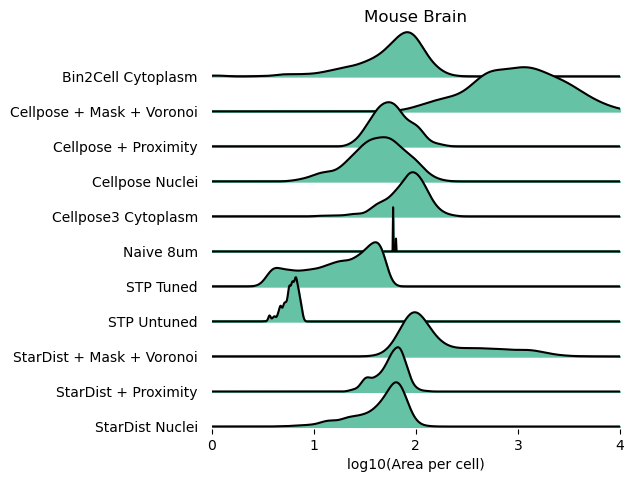

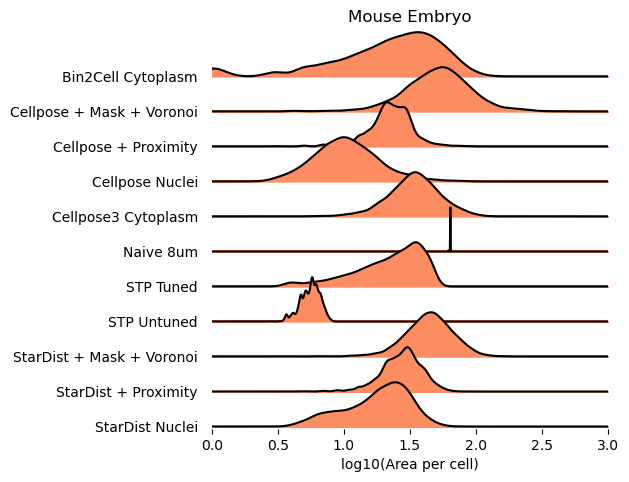

In [16]:
import joypy

# Max tissue
subset = df[df["Tissue"] == chosen_max_tissue].copy()
subset["log_Area_per_cell"] = np.log10(subset["Area_per_cell"] + 1)  # avoid log(0)

fig, axes_list = joypy.joyplot(
    subset,
    by="Sample",
    column="log_Area_per_cell",
    ylim='own',
    title=f'{chosen_max_tissue}',
    overlap=0.3,
    color="#66c2a5"
)

# Set x-axis limits or scale
for ax in axes_list:
    ax.set_xlim(0, 4)
    ax.set_xlabel("log10(Area per cell)")
    ax.set_xlabel("log10(Area per cell)")

fig.savefig(f"benchmark_fig/{chosen_max_tissue}_ridge_plot.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()
plt.close(fig) 

# Min tissue
subset = df[df["Tissue"] == chosen_min_tissue].copy()
subset["log_Area_per_cell"] = np.log10(subset["Area_per_cell"] + 1)

fig, axes_list = joypy.joyplot(
    subset,
    by="Sample",
    column="log_Area_per_cell",
    ylim='own',
    title=f'{chosen_min_tissue}',
    overlap=0.3,
    color="#fc8d62"
)
# Set x-axis limits or scale
for ax in axes_list:
    ax.set_xlim(0, 3)
    ax.set_xlabel("log10(Area per cell)")

fig.savefig(f"benchmark_fig/{chosen_min_tissue}_ridge_plot.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()
plt.close(fig) 
plt.close(fig)


# Cell Density 
Supplemental Figure

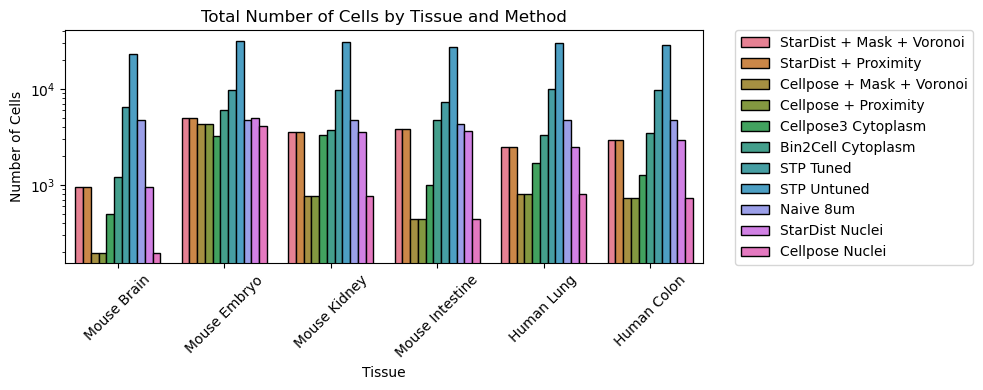

In [17]:
fig, axs = plt.subplots(figsize=(10, 4))

# Plot 3: Total Number of Cells
sns.barplot(
    x="Tissue",
    y="Cell_Count",
    hue="Sample",
    data=num_cells_df,
    edgecolor="black",
    legend=True
)

# Move legend to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

axs.set_ylabel("Number of Cells")
axs.set_xlabel("Tissue")
axs.set_title("Total Number of Cells by Tissue and Method")
axs.tick_params(axis='x', rotation=45)
plt.yscale('log')

plt.tight_layout()
plt.show()


/tmp/ipykernel_2960763/1333602405.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2960763/1333602405.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_2960763/1333602405.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


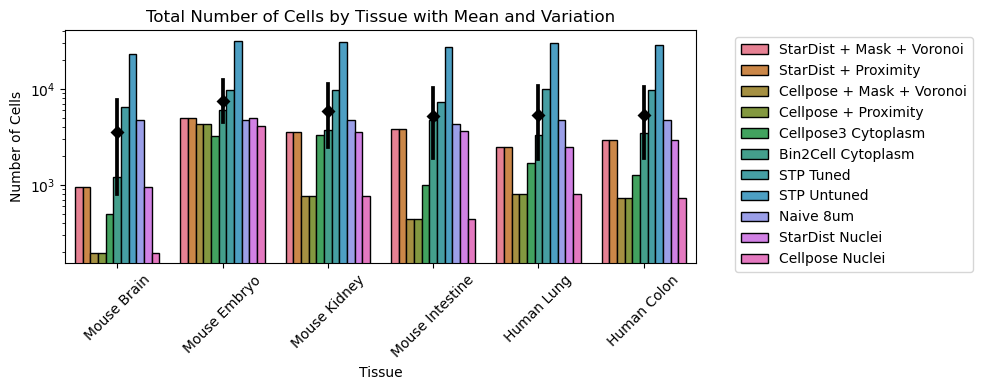

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

# Barplot: totals for each Sample per Tissue
sns.barplot(
    x="Tissue",
    y="Cell_Count",
    hue="Sample",
    data=num_cells_df,
    edgecolor="black",
    ax=ax,
    ci=None  # turn off default CI
)

# Overlay mean + 95% CI for each Tissue
sns.pointplot(
    data=num_cells_df,
    x="Tissue",
    y="Cell_Count",
    color="black",
    join=False,
    errorbar=("ci", 95),
    ax=ax,
    markers="D",       # diamond marker for clarity
    scale=1.0
)

# Move legend to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_ylabel("Number of Cells")
ax.set_xlabel("Tissue")
ax.set_title("Total Number of Cells by Tissue with Mean and Variation")
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')

plt.tight_layout()
plt.show()


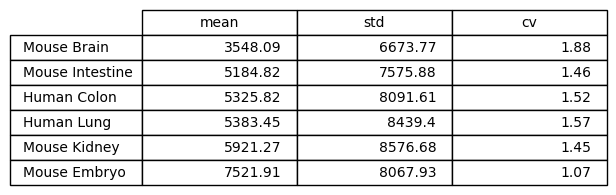

In [19]:
cell_density = num_cells_df.groupby('Tissue')['Cell_Count'].agg(['mean', 'std']).round(2)
cell_density['cv'] = (cell_density['std'] / cell_density['mean']).round(2)

cell_density.sort_values(by='mean', inplace=True)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

tbl = ax.table(
    cellText=cell_density.values,
    colLabels=cell_density.columns,
    rowLabels=cell_density.index,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.show()
